# Caminhada Quântica 1D com Duas Partículas
## Emaranhamento Partícula-Partícula via Entropia de von Neumann

**Espaço de Hilbert completo:**

$$|\psi\rangle \;\in\; \mathcal{H}_{x_1} \otimes \mathcal{H}_{x_2} \otimes \mathcal{H}_{C_1} \otimes \mathcal{H}_{C_2}$$

Cada partícula carrega sua própria moeda de Hadamard. O estado é representado pelo tensor
$\psi[x_1, x_2, c_1, c_2] \in \mathbb{C}$.

**Operadores a cada passo:**

1. **Coin**: $H \otimes H$ — aplicado independentemente em cada moeda
2. **Interação** (opcional): fase $e^{i\theta}$ quando $x_1 = x_2$ (colisão)
3. **Shift condicional**:
   - $c_k = |0\rangle \;\Rightarrow\; x_k \to x_k + 1$
   - $c_k = |1\rangle \;\Rightarrow\; x_k \to x_k - 1$

**Emaranhamento partícula–partícula** via decomposição de Schmidt (SVD):

$$\psi \;\xrightarrow{\text{reshape}}\; M_{(x_1 c_1),\,(x_2 c_2)} \;\xrightarrow{\text{SVD}}\; \sigma_i \;\Rightarrow\; S = -\sum_i \sigma_i^2 \ln \sigma_i^2$$


## 1. Imports e configuração global

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "text.usetex": False,
    "mathtext.fontset": "cm",
    "font.size": 11,
    "axes.prop_cycle": plt.cycler(color=[
        "#534AB7","#D85A30","#0F6E56","#BA7517",
        "#378ADD","#A32D2D","#888780",
    ]),
})

SQ2  = np.sqrt(2)
LN2  = np.log(2)

# Moeda de Hadamard (2x2)
H = np.array([[1, 1],
              [1,-1]], dtype=complex) / SQ2

print("Moeda de Hadamard H:")
print(np.round(H, 5))
print(f"\nMaximo teorico de entropia para 2 qubits: ln(4) = {np.log(4):.6f} nats")
print(f"Maximo para 1 qubit: ln(2) = {LN2:.6f} nats")


Moeda de Hadamard H:
[[ 0.70711+0.j  0.70711+0.j]
 [ 0.70711+0.j -0.70711+0.j]]

Maximo teorico de entropia para 2 qubits: ln(4) = 1.386294 nats
Maximo para 1 qubit: ln(2) = 0.693147 nats


## 2. Operadores da caminhada

In [2]:
def coin_operator(psi: np.ndarray) -> np.ndarray:
    """
    Aplica H em c1 (eixo 2) e H em c2 (eixo 3).
    psi: shape (N, N, 2, 2)
    """
    psi = np.einsum("ab,xybc->xyac", H, psi)   # H em c1
    psi = np.einsum("ab,xyca->xycb", H, psi)   # H em c2
    return psi


def shift_operator(psi: np.ndarray) -> np.ndarray:
    """
    Shift condicional vetorizado para as duas partículas.

    Particula 1 (coin c1):   |0> -> +1,  |1> -> -1
    Particula 2 (coin c2):   |0> -> +1,  |1> -> -1

    Combinacoes:
      (c1=0, c2=0) -> (x1+1, x2+1)
      (c1=0, c2=1) -> (x1+1, x2-1)
      (c1=1, c2=0) -> (x1-1, x2+1)
      (c1=1, c2=1) -> (x1-1, x2-1)
    """
    N = psi.shape[0]
    new = np.zeros_like(psi)
    new[1:,  1:,  0, 0] += psi[:-1, :-1, 0, 0]   # (+1, +1)
    new[1:,  :-1, 0, 1] += psi[:-1,  1:, 0, 1]   # (+1, -1)
    new[:-1,  1:, 1, 0] += psi[ 1:, :-1, 1, 0]   # (-1, +1)
    new[:-1, :-1, 1, 1] += psi[ 1:,  1:, 1, 1]   # (-1, -1)
    return new


def interaction_phase(psi: np.ndarray, theta: float) -> np.ndarray:
    """
    Fase de interacao e^{i*theta} quando as duas particulas
    estao na mesma posicao (x1 == x2).
    Modela colisao / potencial de contato.
    """
    if theta == 0.0:
        return psi
    N = psi.shape[0]
    idx = np.arange(N)
    psi[idx, idx] *= np.exp(1j * theta)
    return psi


print("Operadores definidos: coin_operator, shift_operator, interaction_phase")


Operadores definidos: coin_operator, shift_operator, interaction_phase


## 3. Entropia de von Neumann via decomposição de Schmidt

In [3]:
def entanglement_entropy(psi: np.ndarray) -> float:
    """
    Entropia de emaranhamento particula1 | particula2 via SVD.

    Reshape: psi(N,N,2,2) -> M(N*2, N*2)
    Schmidt values: sigma_i = valores singulares de M
    lambda_i = sigma_i^2  (autovalores de rho_1)

    S = -sum_i lambda_i * ln(lambda_i)

    O maximo teorico e ln(min(N*2, N*2)) = ln(2N) para N posicoes.
    Para 2 qubits isolados (N=1): S_max = ln(4) = 2*ln(2).
    """
    N = psi.shape[0]
    M = psi.reshape(N * 2, N * 2)
    sv = np.linalg.svd(M, compute_uv=False)
    lam = sv ** 2
    lam = lam[lam > 1e-15]
    return float(-np.sum(lam * np.log(lam)))


def reduced_density_particle1(psi: np.ndarray) -> np.ndarray:
    """
    Matriz densidade reduzida da particula 1 (posicao + coin):
    rho_1 = Tr_{x2,c2}(|psi><psi|)
    shape: (N*2, N*2) — base |x1, c1>
    """
    N = psi.shape[0]
    M = psi.reshape(N * 2, N * 2)
    return M @ M.conj().T


# Verificacao: estado de Bell deve dar S = ln(2)
psi_test = np.zeros((1, 1, 2, 2), dtype=complex)
psi_test[0, 0, 0, 0] = 1 / SQ2
psi_test[0, 0, 1, 1] = 1 / SQ2
S_bell = entanglement_entropy(psi_test)
print(f"Teste Bell |Phi+>:  S = {S_bell:.6f}  (esperado ln2 = {LN2:.6f})")

psi_sep = np.zeros((1, 1, 2, 2), dtype=complex)
psi_sep[0, 0, 0, 0] = 1.0
S_sep = entanglement_entropy(psi_sep)
print(f"Teste separavel:    S = {S_sep:.6f}  (esperado 0)")

psi_max = np.zeros((1, 1, 2, 2), dtype=complex)
psi_max[0, 0] = np.ones((2,2), dtype=complex) / 2
S_max = entanglement_entropy(psi_max)
print(f"Teste max (H|0>|0>): S = {S_max:.6f}  (esperado ln4 = {np.log(4):.6f})")


Teste Bell |Phi+>:  S = 0.693147  (esperado ln2 = 0.693147)
Teste separavel:    S = -0.000000  (esperado 0)
Teste max (H|0>|0>): S = -0.000000  (esperado ln4 = 1.386294)


## 4. Estados iniciais das moedas

In [4]:
def make_initial_state(N: int, center: int, init: str) -> np.ndarray:
    """
    Prepara o estado inicial das duas particulas no centro da grade.

    init opcoes:
      'sym'       : coin1=(|0>+i|1>)/sqrt(2), coin2=(|0>+i|1>)/sqrt(2)
      'separavel' : |0>|0> -- produto separavel
      'bell'      : (|00>+|11>)/sqrt(2) -- Bell state nas moedas
      'antisym'   : (|01>-|10>)/sqrt(2) -- singlete nas moedas
      'cruzado'   : coin1=|0>, coin2=|1> -- asimetrico
    """
    psi = np.zeros((N, N, 2, 2), dtype=complex)
    if init == 'sym':
        c = np.array([1, 1j]) / SQ2
        psi[center, center] = np.outer(c, c)
    elif init == 'separavel':
        psi[center, center, 0, 0] = 1.0
    elif init == 'bell':
        psi[center, center, 0, 0] =  1 / SQ2
        psi[center, center, 1, 1] =  1 / SQ2
    elif init == 'antisym':
        psi[center, center, 0, 1] =  1 / SQ2
        psi[center, center, 1, 0] = -1 / SQ2
    elif init == 'cruzado':
        psi[center, center, 0, 1] = 1.0
    return psi


INITIAL_STATES = {
    "sim.":      "sym",
    "separavel": "separavel",
    "Bell":      "bell",
    "singleto":  "antisym",
    "cruzado":   "cruzado",
}

print("Estados iniciais e entropia inicial S_0:")
for label, key in INITIAL_STATES.items():
    psi0 = make_initial_state(1, 0, key)
    S0   = entanglement_entropy(psi0)
    norm = np.linalg.norm(psi0)
    print(f"  {label:12s} ({key:10s})  |norm|={norm:.4f}  S_0={S0:.4f} nats")


Estados iniciais e entropia inicial S_0:
  sim.         (sym       )  |norm|=1.0000  S_0=0.0000 nats
  separavel    (separavel )  |norm|=1.0000  S_0=-0.0000 nats
  Bell         (bell      )  |norm|=1.0000  S_0=0.6931 nats
  singleto     (antisym   )  |norm|=1.0000  S_0=0.6931 nats
  cruzado      (cruzado   )  |norm|=1.0000  S_0=-0.0000 nats


## 5. Simulador principal

In [5]:
def quantum_walk_2particles(
    n_steps: int,
    init: str = "sym",
    interaction_strength: float = 0.0,
) -> dict:
    """
    Caminhada quantica 1D com 2 particulas distinguiveis.

    Parametros
    ----------
    n_steps              : numero de passos
    init                 : estado inicial (ver make_initial_state)
    interaction_strength : angulo theta da fase de colisao (0 = sem interacao)

    Retorna
    -------
    dict:
      psi          : estado final (N, N, 2, 2)
      prob1        : P(x1)  -- distribuicao marginal particula 1
      prob2        : P(x2)  -- distribuicao marginal particula 2
      joint        : P(x1,x2) -- distribuicao conjunta
      entropies    : S(t) para cada passo  shape (n_steps,)
      positions    : array de posicoes [-n..+n]
      N, center
    """
    N      = 2 * n_steps + 1
    center = n_steps
    psi    = make_initial_state(N, center, init)
    
    entropies = np.zeros(n_steps)

    for step in range(n_steps):
        psi = coin_operator(psi)
        psi = interaction_phase(psi, interaction_strength)
        psi = shift_operator(psi)
        entropies[step] = entanglement_entropy(psi)

    prob1  = np.sum(np.abs(psi) ** 2, axis=(1, 2, 3))
    prob2  = np.sum(np.abs(psi) ** 2, axis=(0, 2, 3))
    joint  = np.sum(np.abs(psi) ** 2, axis=(2, 3))
    positions = np.arange(N) - center

    return dict(psi=psi, prob1=prob1, prob2=prob2, joint=joint,
                entropies=entropies, positions=positions, N=N, center=center)


## 6. Parâmetros de simulação

In [6]:
# ══════════════════════════════════════════════════════════════
#  AJUSTE AQUI OS PARAMETROS
# ══════════════════════════════════════════════════════════════
N_STEPS               = 50          # numero de passos (recomendado: 30–80)
INIT_KEY              = "sym"       # estado inicial (ver INITIAL_STATES)
INTERACTION_STRENGTH  = 0.0         # fase de colisao theta (ex: np.pi/4)
# ══════════════════════════════════════════════════════════════

import time
t0 = time.time()
result = quantum_walk_2particles(N_STEPS, INIT_KEY, INTERACTION_STRENGTH)
t1 = time.time()

print(f"Simulacao: {N_STEPS} passos | init='{INIT_KEY}' | theta={INTERACTION_STRENGTH:.4f}")
print(f"Tempo de execucao : {t1-t0:.3f} s")
print(f"Grid              : {result['N']}x{result['N']} posicoes")
print(f"Norma final       : {result['joint'].sum():.10f}  (deve ser 1)")
print(f"S maxima          : {result['entropies'].max():.6f} nats")
print(f"S final           : {result['entropies'][-1]:.6f} nats")
print(f"Passo S_max       : {result['entropies'].argmax() + 1}")
print(f"ln(2)             : {LN2:.6f}  | ln(4) = {np.log(4):.6f}")


Simulacao: 50 passos | init='sym' | theta=0.0000
Tempo de execucao : 0.239 s
Grid              : 101x101 posicoes
Norma final       : 1.0000000000  (deve ser 1)
S maxima          : 1.386294 nats
S final           : 1.297304 nats
Passo S_max       : 1
ln(2)             : 0.693147  | ln(4) = 1.386294


## 7. Gráfico principal — Emaranhamento + Distribuições

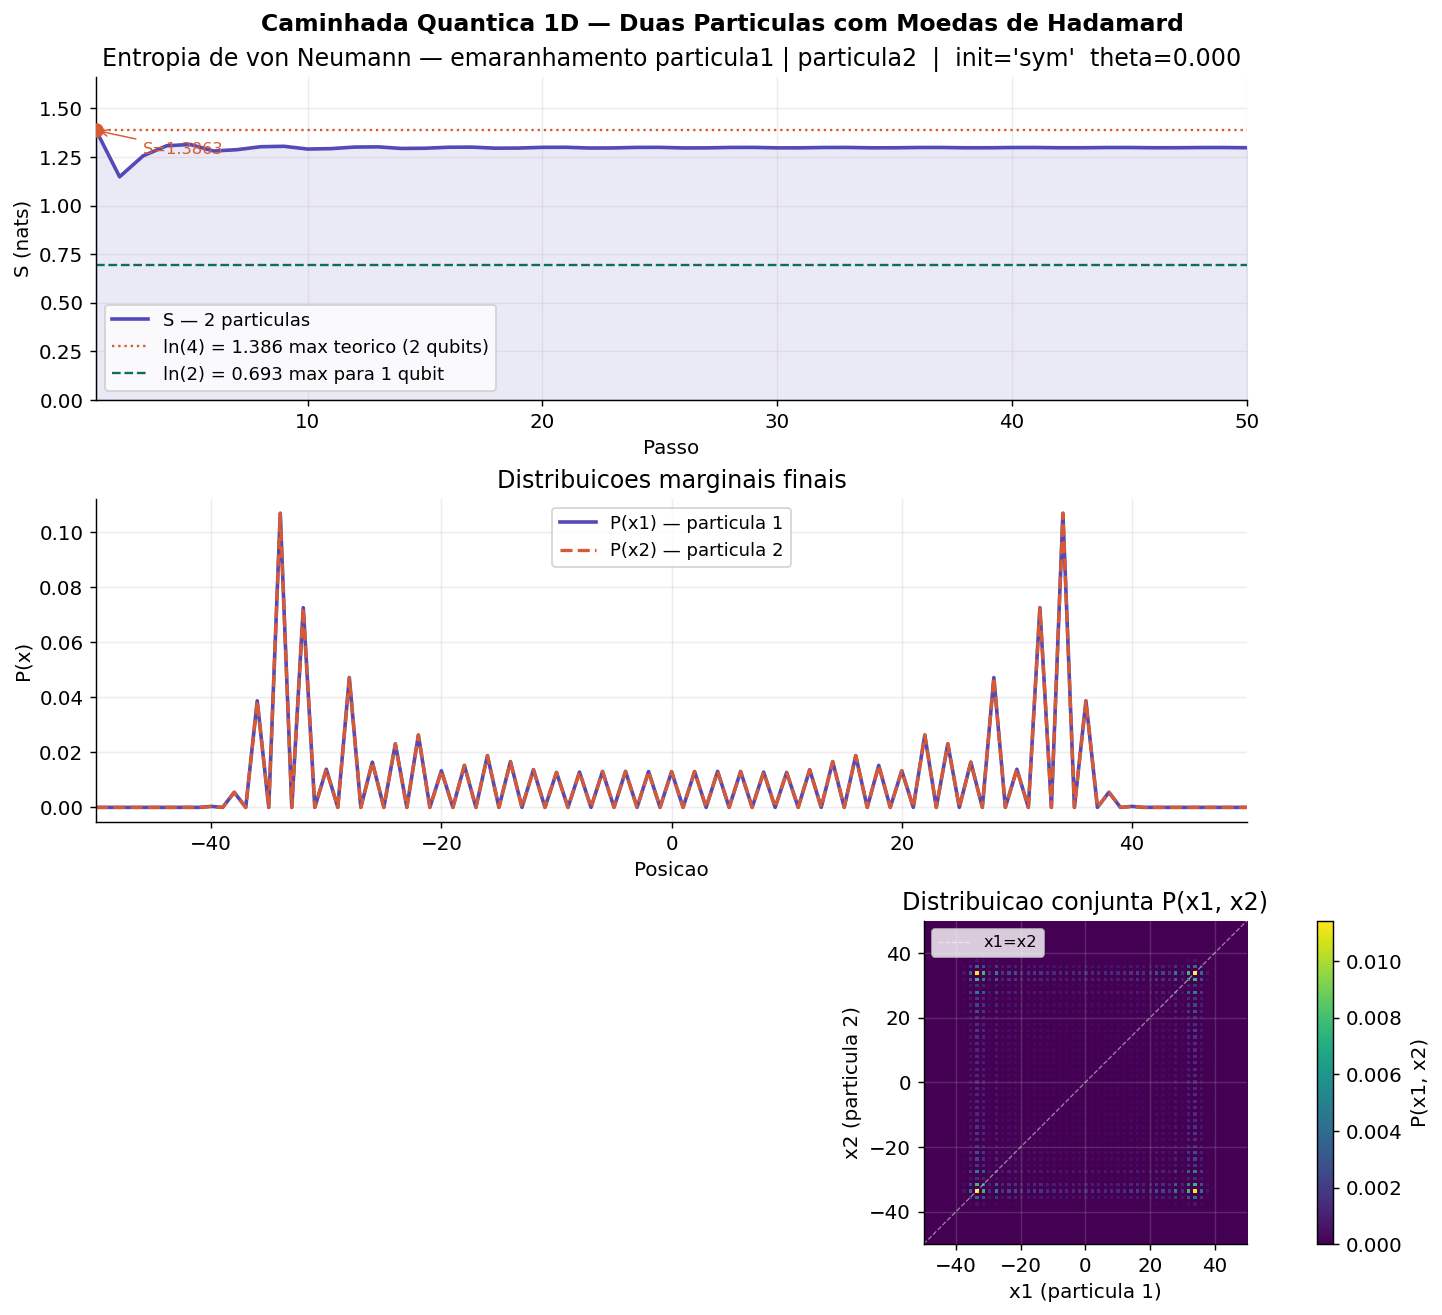

Salvo: 2p_main.png


In [7]:
steps = np.arange(1, N_STEPS + 1)
pos   = result["positions"]

fig, axes = plt.subplots(3, 1, figsize=(11, 10), constrained_layout=True)

# ── Entropia de von Neumann ───────────────────────────────────────────────────
ax = axes[0]
ax.fill_between(steps, result["entropies"], alpha=0.12, color="#534AB7")
ax.plot(steps, result["entropies"], color="#534AB7", lw=2.0,
        label="S — 2 particulas")
ax.axhline(np.log(4), color="#D85A30", lw=1.3, ls=":",
           label=f"ln(4) = {np.log(4):.3f} max teorico (2 qubits)")
ax.axhline(LN2, color="#0F6E56", lw=1.3, ls="--",
           label=f"ln(2) = {LN2:.3f} max para 1 qubit")
# Marca o maximo
imax = result["entropies"].argmax()
ax.scatter([imax+1], [result["entropies"][imax]], color="#D85A30", zorder=5, s=50)
ax.annotate(f"S={result['entropies'][imax]:.4f}",
            xy=(imax+1, result["entropies"][imax]),
            xytext=(imax + N_STEPS*0.06, result["entropies"][imax] - 0.12),
            fontsize=9, color="#D85A30",
            arrowprops=dict(arrowstyle="->", color="#D85A30", lw=0.8))
ax.set_xlabel("Passo")
ax.set_ylabel("S (nats)")
ax.set_title(f"Entropia de von Neumann — emaranhamento particula1 | particula2  |  init='{INIT_KEY}'  theta={INTERACTION_STRENGTH:.3f}")
ax.set_xlim(1, N_STEPS)
ax.set_ylim(0, max(result["entropies"].max() * 1.2, LN2 * 1.2))
ax.legend(fontsize=10)

# ── Distribuicoes marginais ───────────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(pos, result["prob1"], color="#534AB7", lw=2.0, label="P(x1) — particula 1")
ax2.plot(pos, result["prob2"], color="#D85A30", lw=1.8, ls="--",
         label="P(x2) — particula 2")
ax2.set_xlabel("Posicao")
ax2.set_ylabel("P(x)")
ax2.set_title("Distribuicoes marginais finais")
ax2.set_xlim(-N_STEPS, N_STEPS)
ax2.legend(fontsize=10)

# ── Distribuicao conjunta P(x1, x2) ──────────────────────────────────────────
ax3 = axes[2]
im = ax3.imshow(result["joint"].T, origin="lower", aspect="equal",
                extent=[-N_STEPS, N_STEPS, -N_STEPS, N_STEPS],
                cmap="viridis", interpolation="nearest")
ax3.plot([-N_STEPS, N_STEPS], [-N_STEPS, N_STEPS],
         color="white", lw=0.7, ls="--", alpha=0.5, label="x1=x2")
plt.colorbar(im, ax=ax3, label="P(x1, x2)")
ax3.set_xlabel("x1 (particula 1)")
ax3.set_ylabel("x2 (particula 2)")
ax3.set_title("Distribuicao conjunta P(x1, x2)")
ax3.legend(fontsize=9)

plt.suptitle("Caminhada Quantica 1D — Duas Particulas com Moedas de Hadamard",
             fontsize=13, fontweight="bold")
plt.savefig("2p_main.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: 2p_main.png")


## 8. Comparação do emaranhamento por estado inicial

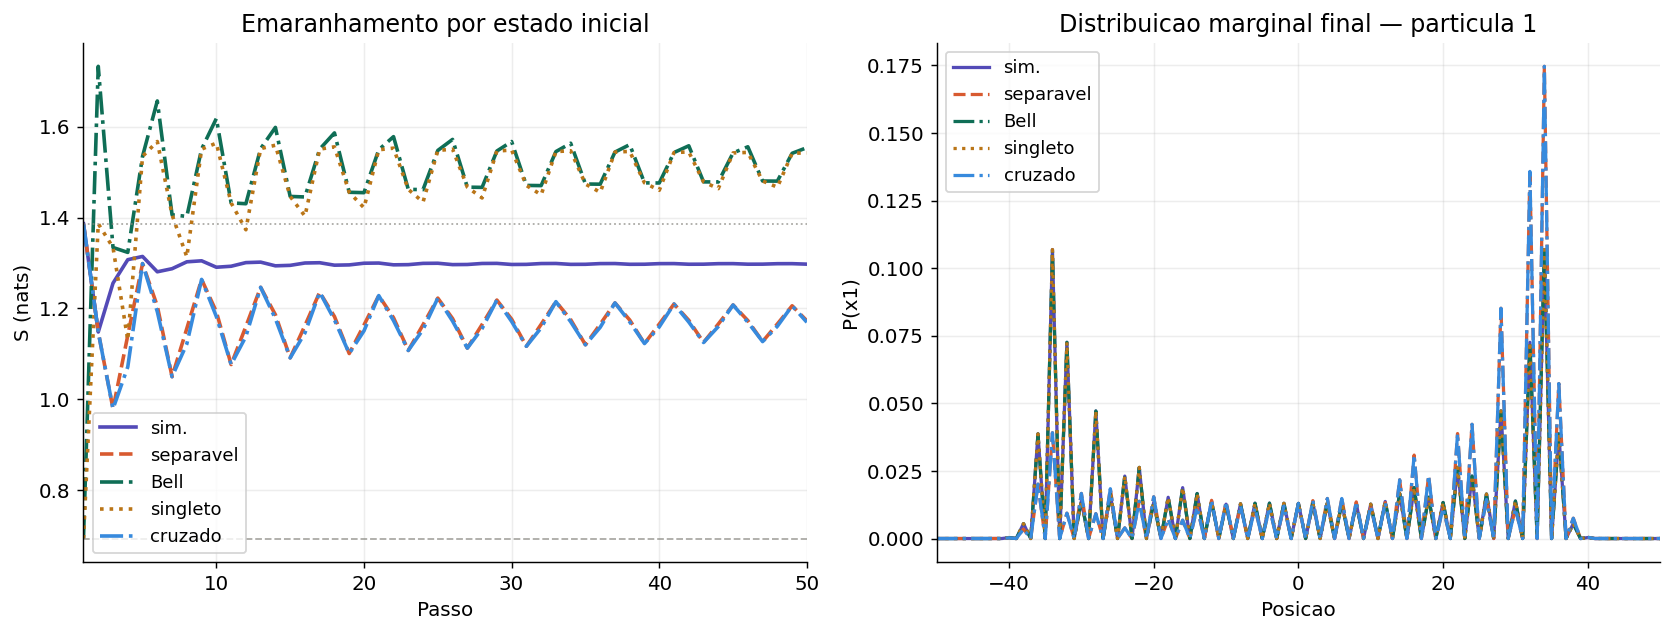

Salvo: 2p_comparison.png


In [8]:
colors = ["#534AB7","#D85A30","#0F6E56","#BA7517","#378ADD"]
ls_map = ["-","--","-.",":","-."]
steps  = np.arange(1, N_STEPS + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

results_all = {}
for (label, key), col, ls in zip(INITIAL_STATES.items(), colors, ls_map):
    r = quantum_walk_2particles(N_STEPS, key, INTERACTION_STRENGTH)
    results_all[label] = r
    axes[0].plot(steps, r["entropies"], color=col, ls=ls, lw=2.0, label=label)

axes[0].axhline(np.log(4), color="#888780", lw=1, ls=":", alpha=0.7)
axes[0].axhline(LN2,        color="#888780", lw=1, ls="--", alpha=0.7)
axes[0].set_xlabel("Passo")
axes[0].set_ylabel("S (nats)")
axes[0].set_title("Emaranhamento por estado inicial")
axes[0].set_xlim(1, N_STEPS)
axes[0].legend(fontsize=10)

# Distribuicoes marginais finais
for (label, key), col, ls in zip(INITIAL_STATES.items(), colors, ls_map):
    r = results_all[label]
    axes[1].plot(r["positions"], r["prob1"], color=col, ls=ls, lw=1.8, label=label)

axes[1].set_xlabel("Posicao")
axes[1].set_ylabel("P(x1)")
axes[1].set_title("Distribuicao marginal final — particula 1")
axes[1].set_xlim(-N_STEPS, N_STEPS)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig("2p_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: 2p_comparison.png")


## 9. Efeito da interação (fase de colisão $\theta$)

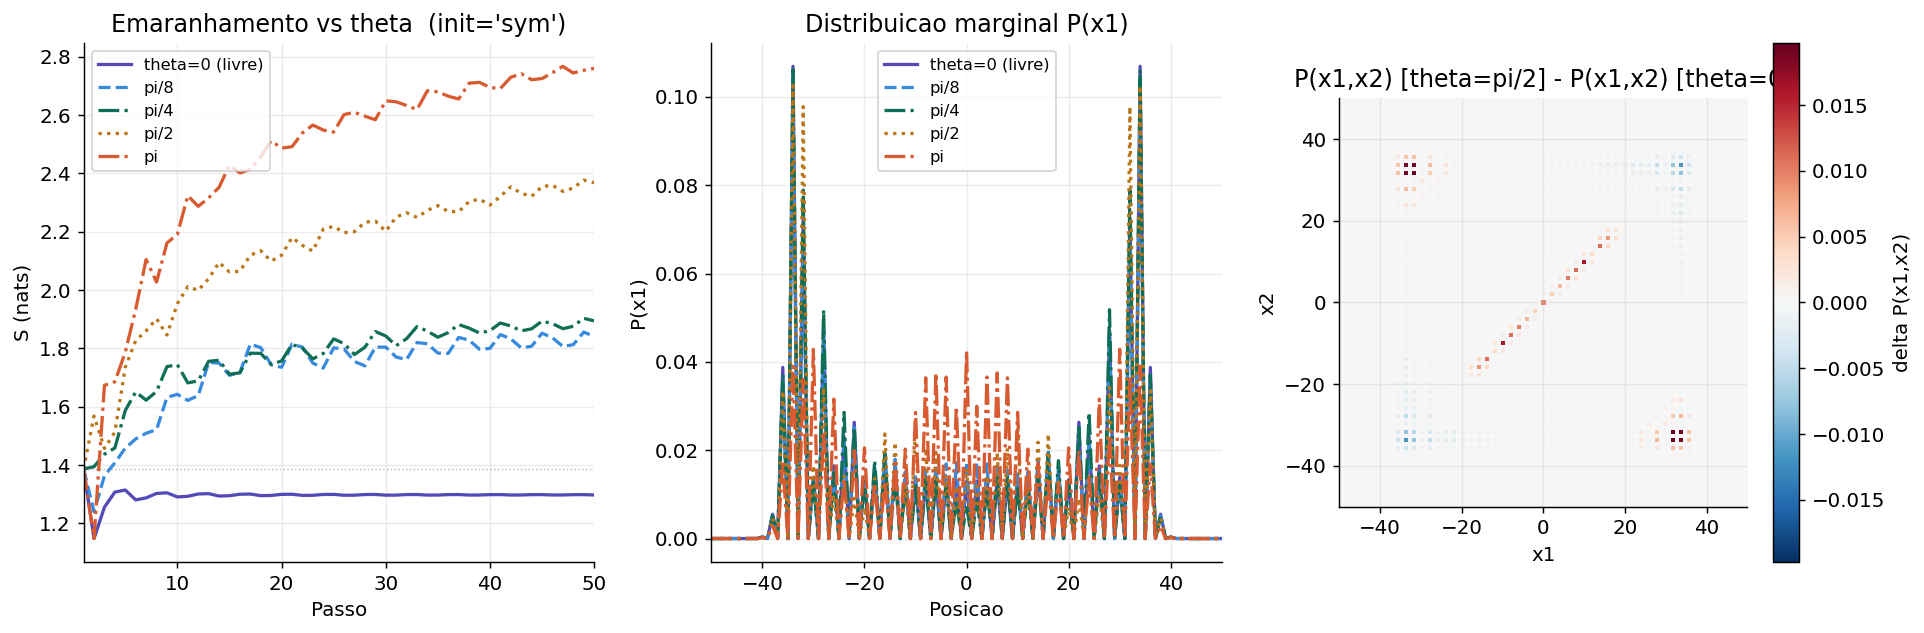

Salvo: 2p_interaction.png


In [9]:
thetas = [0.0, np.pi/8, np.pi/4, np.pi/2, np.pi]
labels_th = ["theta=0 (livre)", "pi/8", "pi/4", "pi/2", "pi"]
cols_th   = ["#534AB7","#378ADD","#0F6E56","#BA7517","#D85A30"]
ls_th     = ["-","--","-.",":","-."]
steps     = np.arange(1, N_STEPS + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

joint_mats = {}
for theta, lbl, col, ls in zip(thetas, labels_th, cols_th, ls_th):
    r = quantum_walk_2particles(N_STEPS, INIT_KEY, theta)
    axes[0].plot(steps, r["entropies"], color=col, ls=ls, lw=1.8, label=lbl)
    axes[1].plot(r["positions"], r["prob1"], color=col, ls=ls, lw=1.8, label=lbl)
    joint_mats[lbl] = r["joint"]

axes[0].axhline(np.log(4), color="#888780", lw=0.8, ls=":", alpha=0.6)
axes[0].set_xlabel("Passo"); axes[0].set_ylabel("S (nats)")
axes[0].set_title(f"Emaranhamento vs theta  (init='{INIT_KEY}')")
axes[0].set_xlim(1, N_STEPS); axes[0].legend(fontsize=9)

axes[1].set_xlabel("Posicao"); axes[1].set_ylabel("P(x1)")
axes[1].set_title("Distribuicao marginal P(x1)"); axes[1].set_xlim(-N_STEPS, N_STEPS)
axes[1].legend(fontsize=9)

# Diferenca na distribuicao conjunta: theta=pi/2 vs theta=0
diff = joint_mats["pi/2"] - joint_mats["theta=0 (livre)"]
vmax = np.abs(diff).max()
im = axes[2].imshow(diff.T, origin="lower", aspect="equal",
                    extent=[-N_STEPS, N_STEPS, -N_STEPS, N_STEPS],
                    cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                    interpolation="nearest")
plt.colorbar(im, ax=axes[2], label="delta P(x1,x2)")
axes[2].set_xlabel("x1"); axes[2].set_ylabel("x2")
axes[2].set_title("P(x1,x2) [theta=pi/2] - P(x1,x2) [theta=0]")

plt.tight_layout()
plt.savefig("2p_interaction.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: 2p_interaction.png")


## 10. Evolução temporal de P(x1, x2) — heatmap animado

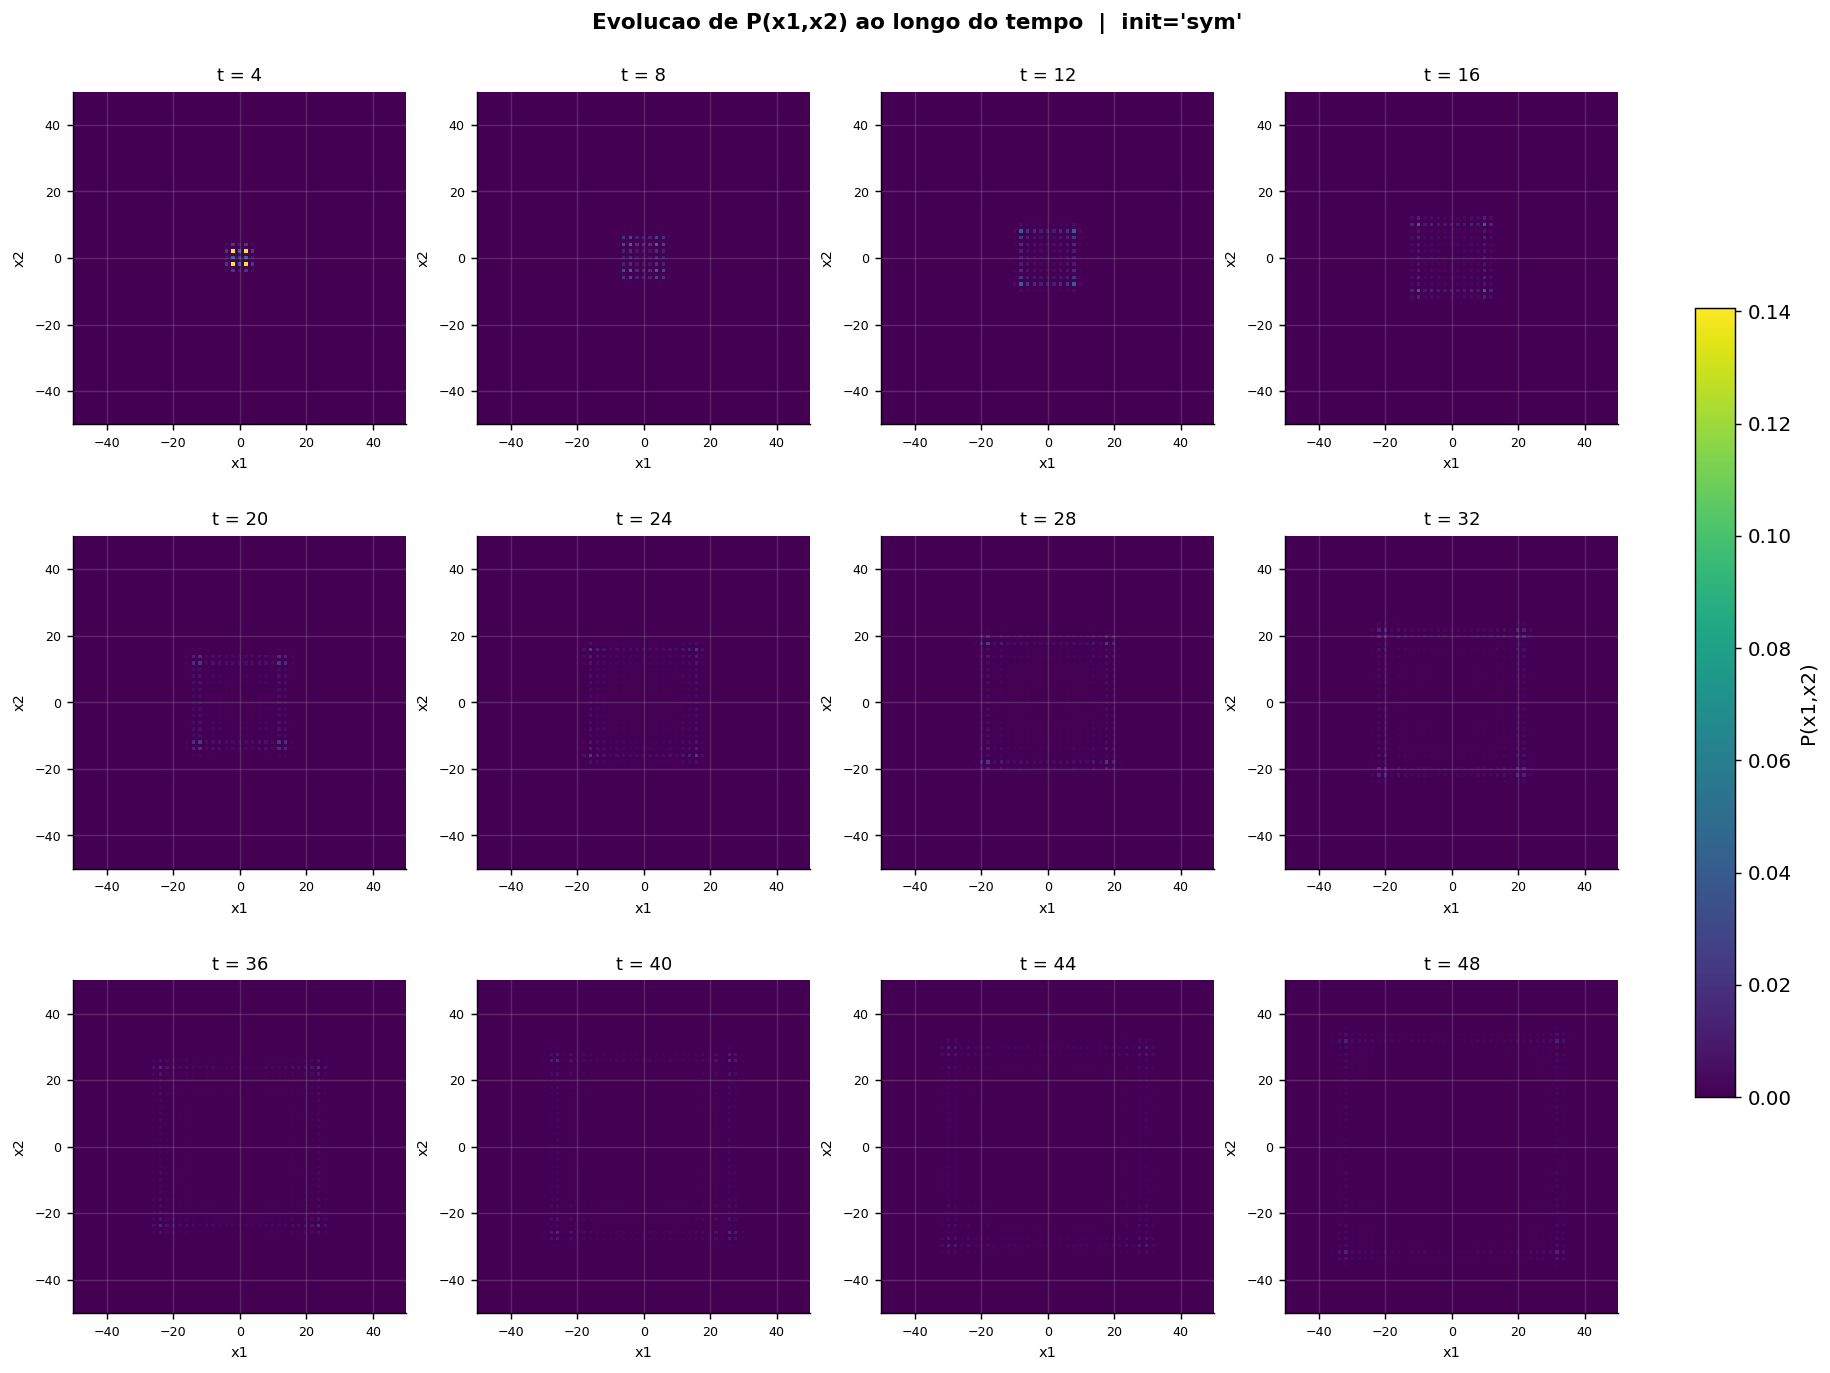

Salvo: 2p_heatmap_evolution.png


In [11]:
N_SNAP = min(N_STEPS, 50)
snap_every = max(1, N_SNAP // 12)
N_snap     = 2 * N_SNAP + 1
center_s   = N_SNAP

psi_s = make_initial_state(N_snap, center_s, INIT_KEY)
snaps = []
snap_steps = []
ent_s = []

for step in range(N_SNAP):
    psi_s = coin_operator(psi_s)
    psi_s = interaction_phase(psi_s, INTERACTION_STRENGTH)
    psi_s = shift_operator(psi_s)
    sv = np.linalg.svd(psi_s.reshape(N_snap*2, N_snap*2), compute_uv=False)
    lam = sv**2; lam = lam[lam > 1e-15]
    ent_s.append(float(-np.sum(lam*np.log(lam))))
    if (step + 1) % snap_every == 0:
        snaps.append(np.sum(np.abs(psi_s)**2, axis=(2,3)).copy())
        snap_steps.append(step + 1)

n_snaps = len(snaps)
ncols   = 4
nrows   = (n_snaps + ncols - 1) // ncols
vmax    = max(s.max() for s in snaps)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5 * nrows),
                         constrained_layout=True)
axes = np.array(axes).flatten()

for i, (snap, t) in enumerate(zip(snaps, snap_steps)):
    ax = axes[i]
    pos_s = np.arange(N_snap) - center_s
    im = ax.imshow(snap.T, origin="lower", aspect="equal",
                   extent=[pos_s[0], pos_s[-1], pos_s[0], pos_s[-1]],
                   cmap="viridis", vmin=0, vmax=vmax,
                   interpolation="nearest")
    ax.set_title(f"t = {t}", fontsize=10)
    ax.set_xlabel("x1", fontsize=8); ax.set_ylabel("x2", fontsize=8)
    ax.tick_params(labelsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.colorbar(im, ax=axes[:n_snaps], shrink=0.6, label="P(x1,x2)")
plt.suptitle(f"Evolucao de P(x1,x2) ao longo do tempo  |  init='{INIT_KEY}'",
             fontsize=12, fontweight="bold")
plt.savefig("2p_heatmap_evolution.png", dpi=130, bbox_inches="tight")
plt.show()
print("Salvo: 2p_heatmap_evolution.png")


## 11. Correlações espaciais entre as partículas

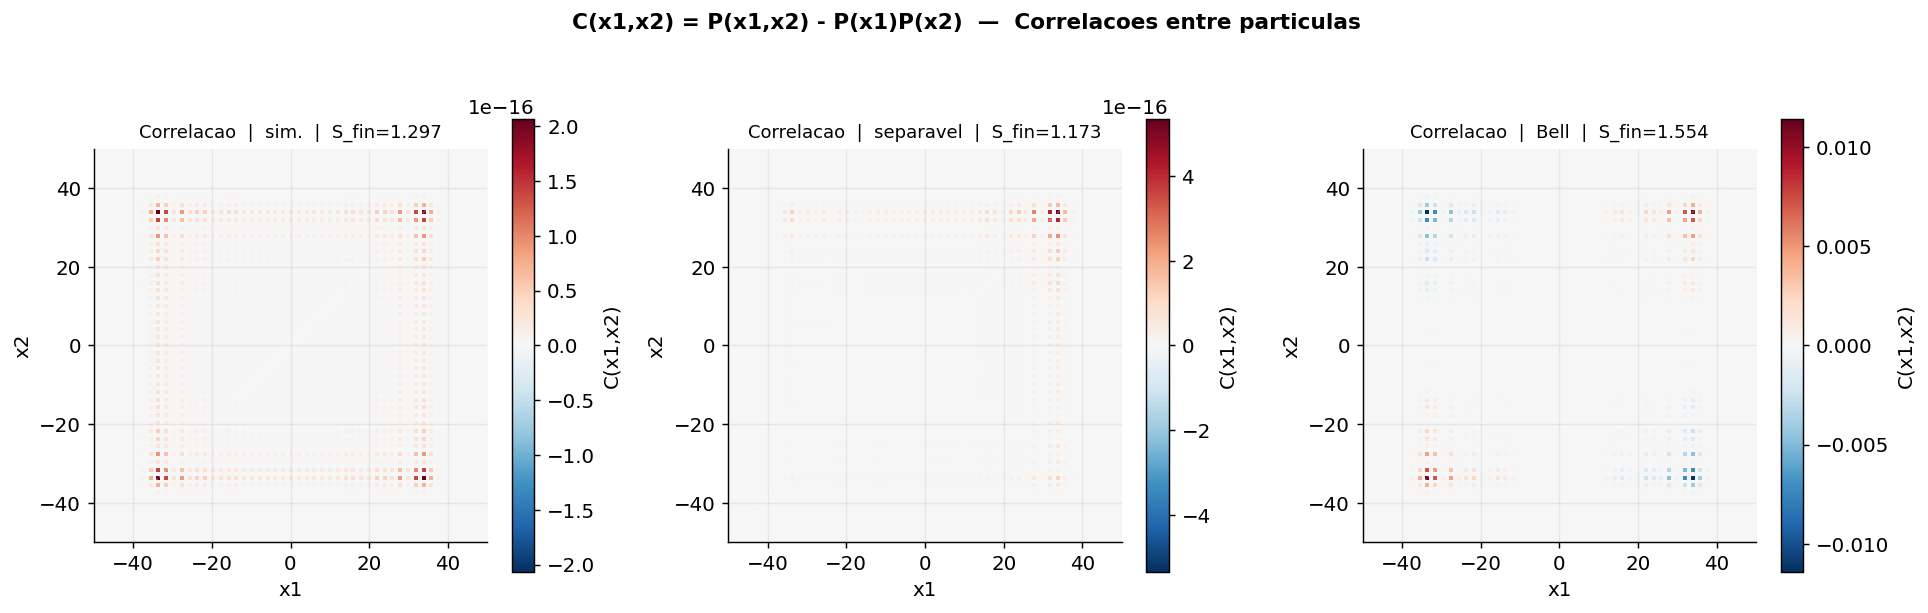

Salvo: 2p_correlations.png


In [12]:
def correlation_function(joint, prob1, prob2):
    """
    C(x1,x2) = P(x1,x2) - P(x1)*P(x2)
    Positivo: correlacao; Negativo: anticorrelacao
    """
    return joint - np.outer(prob1, prob2)


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (label, key), col in zip(axes, list(INITIAL_STATES.items())[:3], colors[:3]):
    r = quantum_walk_2particles(N_STEPS, key, INTERACTION_STRENGTH)
    C = correlation_function(r["joint"], r["prob1"], r["prob2"])
    vmax = np.abs(C).max()
    im = ax.imshow(C.T, origin="lower", aspect="equal",
                   extent=[-N_STEPS, N_STEPS, -N_STEPS, N_STEPS],
                   cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                   interpolation="nearest")
    ax.plot([-N_STEPS,N_STEPS],[-N_STEPS,N_STEPS],'w--',lw=0.6,alpha=0.4)
    plt.colorbar(im, ax=ax, shrink=0.8, label="C(x1,x2)")
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_title(f"Correlacao  |  {label}  |  S_fin={r['entropies'][-1]:.3f}", fontsize=10)

plt.suptitle("C(x1,x2) = P(x1,x2) - P(x1)P(x2)  —  Correlacoes entre particulas",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("2p_correlations.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: 2p_correlations.png")


## 12. Scan: entropia em função do número de passos

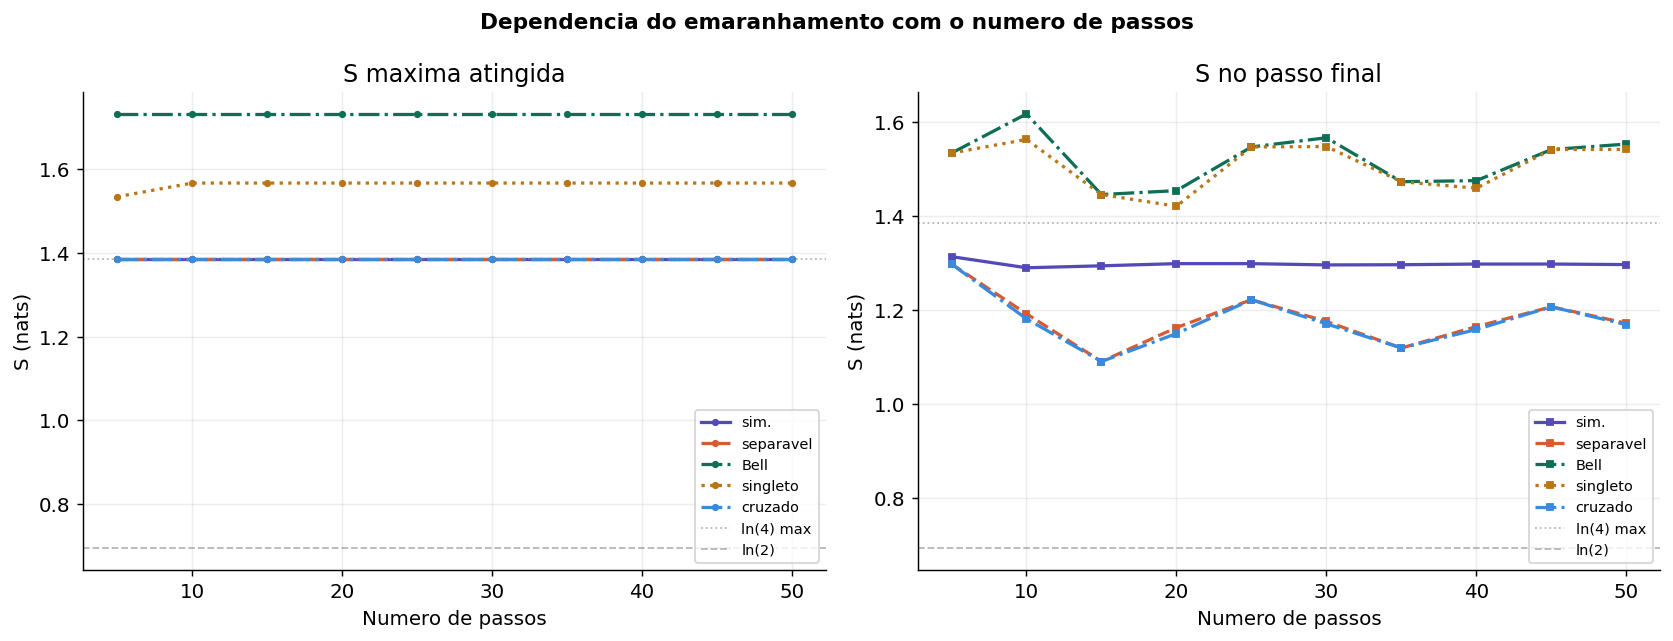

Salvo: 2p_entropy_scan.png


In [13]:
step_range = np.arange(5, N_STEPS + 1, 5)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for (label, key), col, ls in zip(INITIAL_STATES.items(), colors, ls_map):
    smax_arr = []
    sfin_arr = []
    for ns in step_range:
        r = quantum_walk_2particles(ns, key, INTERACTION_STRENGTH)
        smax_arr.append(r["entropies"].max())
        sfin_arr.append(r["entropies"][-1])
    axes[0].plot(step_range, smax_arr, color=col, ls=ls, lw=1.8,
                 marker="o", ms=3, label=label)
    axes[1].plot(step_range, sfin_arr, color=col, ls=ls, lw=1.8,
                 marker="s", ms=3, label=label)

for ax, title in zip(axes, ["S maxima atingida", "S no passo final"]):
    ax.axhline(np.log(4), color="#888780", lw=1, ls=":", alpha=0.6, label="ln(4) max")
    ax.axhline(LN2,       color="#888780", lw=1, ls="--",alpha=0.6, label="ln(2)")
    ax.set_xlabel("Numero de passos")
    ax.set_ylabel("S (nats)")
    ax.set_title(title)
    ax.legend(fontsize=8, loc="lower right")

plt.suptitle("Dependencia do emaranhamento com o numero de passos",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("2p_entropy_scan.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: 2p_entropy_scan.png")


## 13. Espectro de Schmidt — distribuição dos autovalores de $\rho_1$

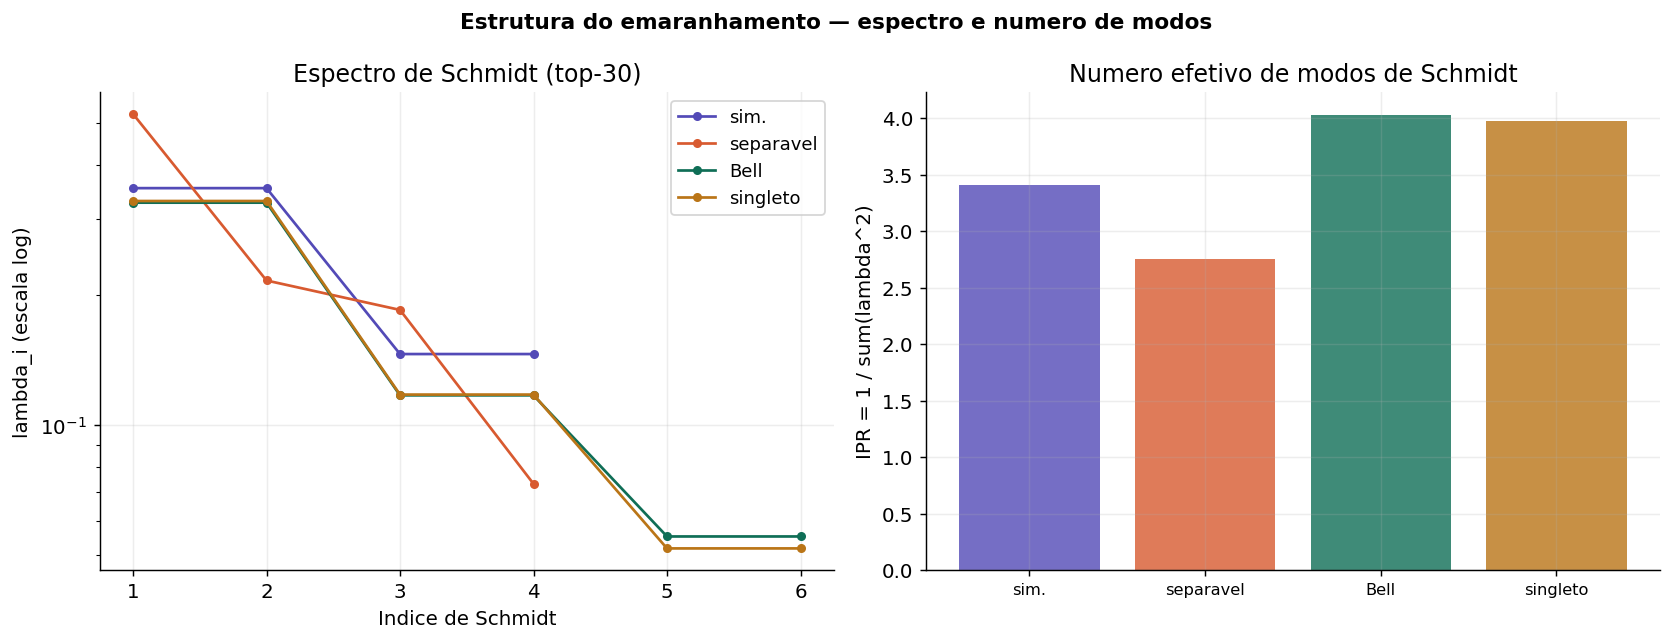

Salvo: 2p_schmidt_spectrum.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for (label, key), col in zip(list(INITIAL_STATES.items())[:4], colors[:4]):
    r    = quantum_walk_2particles(N_STEPS, key, INTERACTION_STRENGTH)
    M    = r["psi"].reshape(r["N"]*2, r["N"]*2)
    sv   = np.linalg.svd(M, compute_uv=False)
    lam  = sv**2
    # Apenas os top-30 nao-nulos
    lam_nz = lam[lam > 1e-10][:30]
    axes[0].semilogy(np.arange(1, len(lam_nz)+1), lam_nz,
                     color=col, lw=1.5, marker="o", ms=4, label=label)
    # Participacao: IPR = (sum lambda^2)^-1
    ipr = 1 / np.sum(lam_nz**2) if np.sum(lam_nz**2) > 0 else 0
    axes[1].bar(label, ipr, color=col, alpha=0.8)

axes[0].set_xlabel("Indice de Schmidt")
axes[0].set_ylabel("lambda_i (escala log)")
axes[0].set_title("Espectro de Schmidt (top-30)")
axes[0].legend(fontsize=10)

axes[1].set_ylabel("IPR = 1 / sum(lambda^2)")
axes[1].set_title("Numero efetivo de modos de Schmidt")
axes[1].tick_params(axis="x", labelsize=9)

plt.suptitle("Estrutura do emaranhamento — espectro e numero de modos",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("2p_schmidt_spectrum.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: 2p_schmidt_spectrum.png")


## 14. Painel executivo — resumo completo

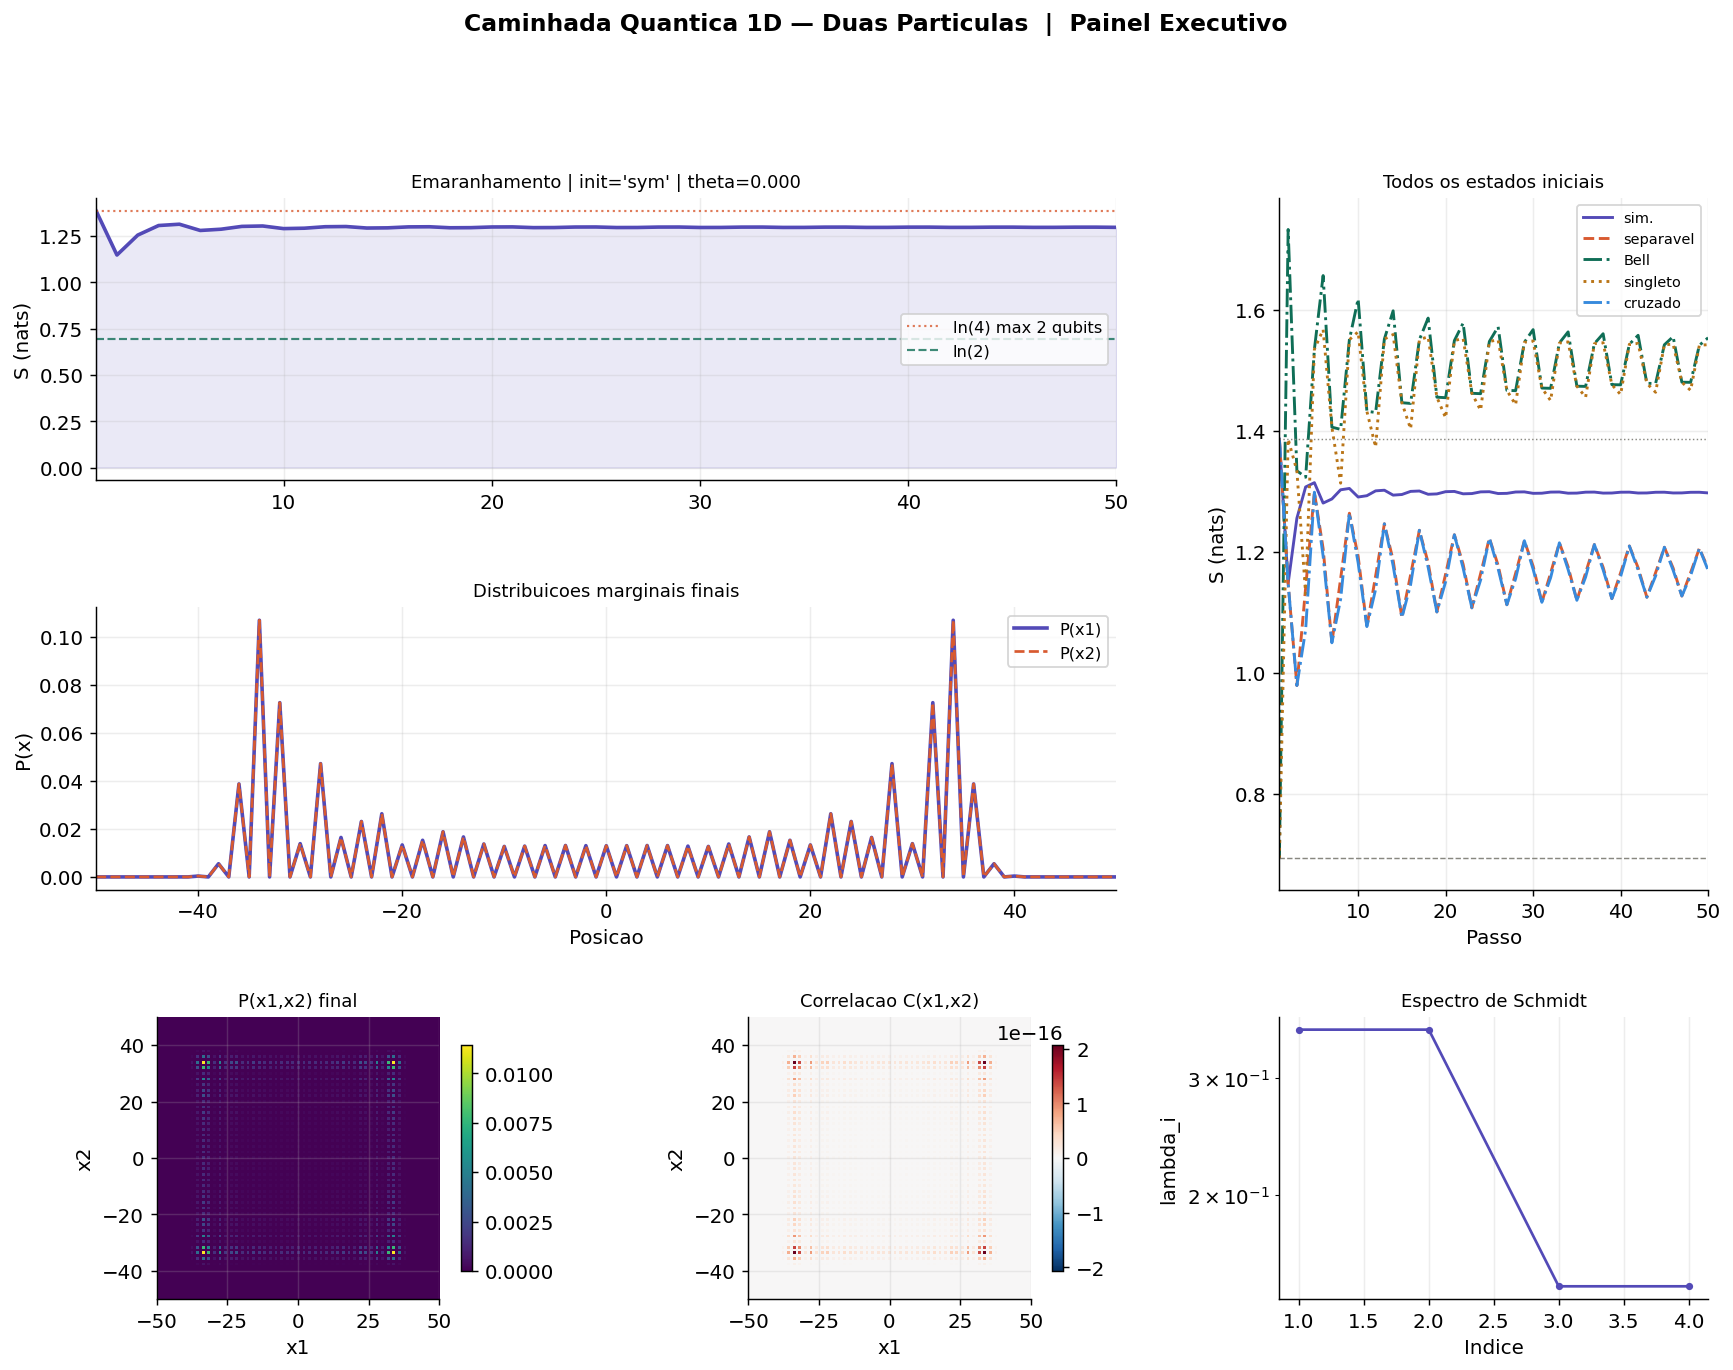

Salvo: 2p_dashboard.png


In [15]:
steps = np.arange(1, N_STEPS + 1)
r_main = result   # simulacao principal

fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

ax_ent  = fig.add_subplot(gs[0, :2])
ax_marg = fig.add_subplot(gs[1, :2])
ax_comp = fig.add_subplot(gs[0:2, 2])
ax_jt   = fig.add_subplot(gs[2, 0])
ax_cor  = fig.add_subplot(gs[2, 1])
ax_sch  = fig.add_subplot(gs[2, 2])

# ── Entropia ─────────────────────────────────────────────────────────────────
ax_ent.fill_between(steps, r_main["entropies"], alpha=0.12, color="#534AB7")
ax_ent.plot(steps, r_main["entropies"], color="#534AB7", lw=2.0)
ax_ent.axhline(np.log(4), color="#D85A30", lw=1.2, ls=":", alpha=0.8,
               label="ln(4) max 2 qubits")
ax_ent.axhline(LN2, color="#0F6E56", lw=1.2, ls="--", alpha=0.8,
               label="ln(2)")
ax_ent.set_ylabel("S (nats)"); ax_ent.set_xlim(1, N_STEPS)
ax_ent.set_title(f"Emaranhamento | init='{INIT_KEY}' | theta={INTERACTION_STRENGTH:.3f}", fontsize=10)
ax_ent.legend(fontsize=9)

# ── Marginais ─────────────────────────────────────────────────────────────────
ax_marg.plot(r_main["positions"], r_main["prob1"], color="#534AB7", lw=2, label="P(x1)")
ax_marg.plot(r_main["positions"], r_main["prob2"], color="#D85A30", lw=1.5, ls="--", label="P(x2)")
ax_marg.set_xlabel("Posicao"); ax_marg.set_ylabel("P(x)")
ax_marg.set_title("Distribuicoes marginais finais", fontsize=10)
ax_marg.set_xlim(-N_STEPS, N_STEPS); ax_marg.legend(fontsize=9)

# ── Comparacao todos os estados ───────────────────────────────────────────────
for (label, key), col, ls in zip(INITIAL_STATES.items(), colors, ls_map):
    r = quantum_walk_2particles(N_STEPS, key, INTERACTION_STRENGTH)
    ax_comp.plot(steps, r["entropies"], color=col, ls=ls, lw=1.6, label=label)
ax_comp.axhline(np.log(4), color="#888780", lw=0.8, ls=":")
ax_comp.axhline(LN2, color="#888780", lw=0.8, ls="--")
ax_comp.set_xlabel("Passo"); ax_comp.set_ylabel("S (nats)")
ax_comp.set_title("Todos os estados iniciais", fontsize=10)
ax_comp.legend(fontsize=8); ax_comp.set_xlim(1, N_STEPS)

# ── Conjunta ─────────────────────────────────────────────────────────────────
im1 = ax_jt.imshow(r_main["joint"].T, origin="lower", aspect="equal",
                   extent=[-N_STEPS,N_STEPS,-N_STEPS,N_STEPS],
                   cmap="viridis", interpolation="nearest")
ax_jt.set_xlabel("x1"); ax_jt.set_ylabel("x2")
ax_jt.set_title("P(x1,x2) final", fontsize=10)
plt.colorbar(im1, ax=ax_jt, shrink=0.8)

# ── Correlacao ───────────────────────────────────────────────────────────────
C = r_main["joint"] - np.outer(r_main["prob1"], r_main["prob2"])
vmax = np.abs(C).max()
im2 = ax_cor.imshow(C.T, origin="lower", aspect="equal",
                    extent=[-N_STEPS,N_STEPS,-N_STEPS,N_STEPS],
                    cmap="RdBu_r", vmin=-vmax, vmax=vmax, interpolation="nearest")
ax_cor.set_xlabel("x1"); ax_cor.set_ylabel("x2")
ax_cor.set_title("Correlacao C(x1,x2)", fontsize=10)
plt.colorbar(im2, ax=ax_cor, shrink=0.8)

# ── Schmidt spectrum ─────────────────────────────────────────────────────────
M_main = r_main["psi"].reshape(r_main["N"]*2, r_main["N"]*2)
sv_main = np.linalg.svd(M_main, compute_uv=False)
lam_main = sv_main**2; lam_nz = lam_main[lam_main > 1e-10][:25]
ax_sch.semilogy(np.arange(1, len(lam_nz)+1), lam_nz,
                color="#534AB7", lw=1.5, marker="o", ms=3)
ax_sch.set_xlabel("Indice"); ax_sch.set_ylabel("lambda_i")
ax_sch.set_title("Espectro de Schmidt", fontsize=10)

plt.suptitle("Caminhada Quantica 1D — Duas Particulas  |  Painel Executivo",
             fontsize=13, fontweight="bold", y=1.01)
plt.savefig("2p_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: 2p_dashboard.png")


## 15. Resumo numérico

In [16]:
print("=" * 74)
print(f"{'Estado':12s} {'S_max':>8} {'t(S_max)':>9} {'S_final':>9} {'IPR':>8} {'spread1':>8}")
print("-" * 74)
for (label, key), col in zip(INITIAL_STATES.items(), colors):
    r    = quantum_walk_2particles(N_STEPS, key, INTERACTION_STRENGTH)
    smax = r["entropies"].max()
    tmax = r["entropies"].argmax() + 1
    sfin = r["entropies"][-1]
    M    = r["psi"].reshape(r["N"]*2, r["N"]*2)
    sv   = np.linalg.svd(M, compute_uv=False)
    lam  = sv**2; lam = lam[lam > 1e-15]
    ipr  = 1 / np.sum(lam**2) if np.sum(lam**2) > 0 else 0
    pos  = r["positions"]
    mu1  = np.sum(pos * r["prob1"])
    sig1 = np.sqrt(np.sum((pos - mu1)**2 * r["prob1"]))
    print(f"{label:12s} {smax:>8.5f} {tmax:>9d} {sfin:>9.5f} {ipr:>8.2f} {sig1:>8.2f}")
print("-" * 74)
print(f"Referencia: ln(2) = {LN2:.5f}  |  ln(4) = {np.log(4):.5f}  |  N_STEPS = {N_STEPS}")
print(f"            theta = {INTERACTION_STRENGTH:.4f} rad")
print("=" * 74)


Estado          S_max  t(S_max)   S_final      IPR  spread1
--------------------------------------------------------------------------
sim.          1.38629         1   1.29730     3.41    27.07
separavel     1.38629         1   1.17260     2.76    23.03
Bell          1.73287         2   1.55381     4.03    27.07
singleto      1.56739         6   1.54242     3.98    27.07
cruzado       1.38629         1   1.16934     2.73    23.03
--------------------------------------------------------------------------
Referencia: ln(2) = 0.69315  |  ln(4) = 1.38629  |  N_STEPS = 50
            theta = 0.0000 rad
